## Linear Regression Model for Customer Churn

I am using linear regression as an interpretable baseline for churn. Since churn is a `0/1` outcome, the predictions are treated as churn-risk scores rather than perfect class labels.

The goal is to understand which customer features are associated with higher or lower churn risk.

### 1. Dataset Loading and Initial Check

First I load the CSV directly from the `data` folder and look at the raw dataset before making cleaning decisions.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("default")
RANDOM_STATE = 42

In [2]:
data_path = Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw = pd.read_csv(data_path)

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Missing values check

Before dropping anything, I check missing values and blank strings. This matters because `TotalCharges` looks numeric, but in this dataset it is stored as text.

In [3]:
missing_check = pd.DataFrame(
    {
        "dtype": df_raw.dtypes.astype(str),
        "missing_count": df_raw.isna().sum(),
        "blank_string_count": df_raw.astype("string").apply(lambda col: col.str.strip().eq("").sum()),
    }
)

missing_check.sort_values(["missing_count", "blank_string_count"], ascending=False)

,dtype,missing_count,blank_string_count
TotalCharges,object,0,11
customerID,object,0,0
gender,object,0,0
SeniorCitizen,int64,0,0
Partner,object,0,0
Dependents,object,0,0
tenure,int64,0,0
PhoneService,object,0,0
MultipleLines,object,0,0
InternetService,object,0,0


`TotalCharges` has a small number of blank strings. I convert it to numeric first, then remove only the rows where that conversion creates missing values.

In [4]:
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after converting TotalCharges:")
print(df.isna().sum().sort_values(ascending=False).head())

rows_before = len(df)
df = df.dropna(subset=["TotalCharges"]).copy()
rows_removed = rows_before - len(df)

print()
print(f"Rows removed: {rows_removed}")
print(f"Cleaned shape: {df.shape}")

Missing values after converting TotalCharges:
TotalCharges        11
customerID           0
DeviceProtection     0
MonthlyCharges       0
PaymentMethod        0
dtype: int64

Rows removed: 11
Cleaned shape: (7032, 21)


Now I create the binary target and remove `customerID`, which is only an identifier.

In [5]:
df["ChurnFlag"] = df["Churn"].map({"No": 0, "Yes": 1})
df = df.drop(columns=["customerID"])

df[["Churn", "ChurnFlag"]].head()

,Churn,ChurnFlag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


### 2. EDA and Pre-Fit Assumption Checks

Before fitting the model, I check target balance, feature distributions, feature relationships, correlations, and multicollinearity. I use these checks as evidence before deciding whether to simplify or remove variables.

Target balance:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Target proportions:
Churn
No     0.734
Yes    0.266
Name: proportion, dtype: float64


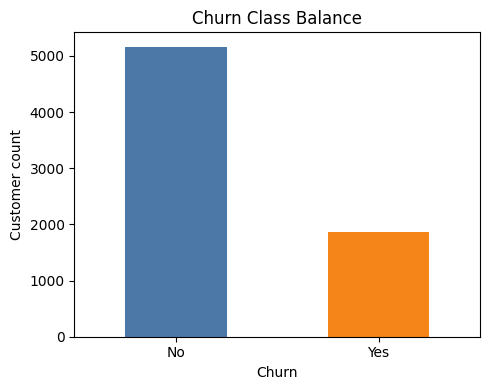

In [6]:
print("Target balance:")
print(df["Churn"].value_counts())
print()
print("Target proportions:")
print(df["Churn"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 4))
df["Churn"].value_counts().reindex(["No", "Yes"]).plot(
    kind="bar",
    ax=ax,
    color=["#4c78a8", "#f58518"],
)
ax.set_title("Churn Class Balance")
ax.set_xlabel("Churn")
ax.set_ylabel("Customer count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [7]:
numeric_features = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [
    col for col in df.columns
    if col not in numeric_features + ["Churn", "ChurnFlag"]
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

df[numeric_features + ["ChurnFlag"]].describe().round(2)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChurnFlag
count,7032.00,7032.00,7032.00,7032.00,7032.00
mean,0.16,32.42,64.80,2283.30,0.27
std,0.37,24.55,30.09,2266.77,0.44
min,0.00,1.00,18.25,18.80,0.00
25%,0.00,9.00,35.59,401.45,0.00
50%,0.00,29.00,70.35,1397.48,0.00
75%,0.00,55.00,89.86,3794.74,1.00
max,1.00,72.00,118.75,8684.80,1.00


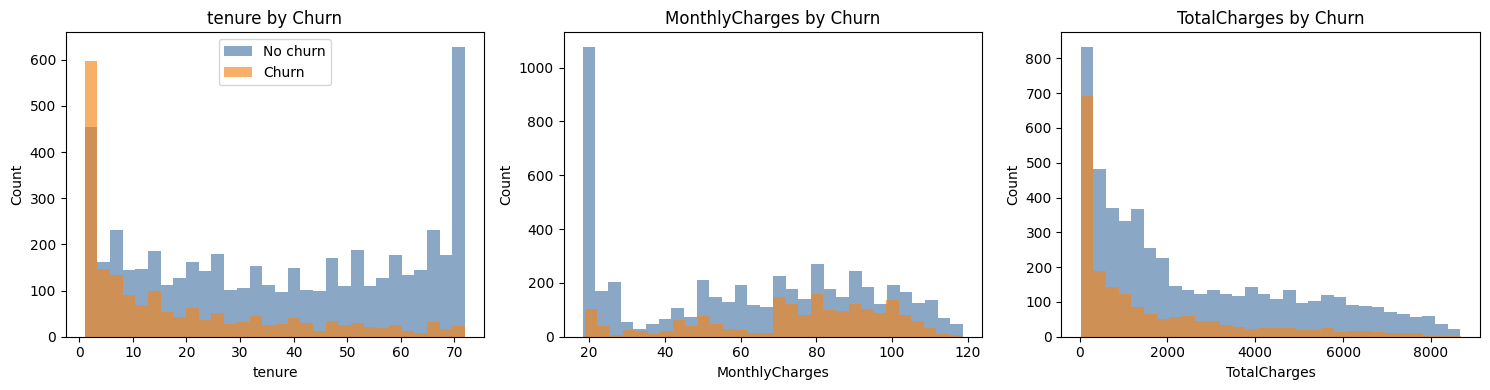

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    ax.hist(df.loc[df["ChurnFlag"] == 0, col], bins=30, alpha=0.65, label="No churn", color="#4c78a8")
    ax.hist(df.loc[df["ChurnFlag"] == 1, col], bins=30, alpha=0.65, label="Churn", color="#f58518")
    ax.set_title(f"{col} by Churn")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
axes[0].legend()
plt.tight_layout()
plt.show()

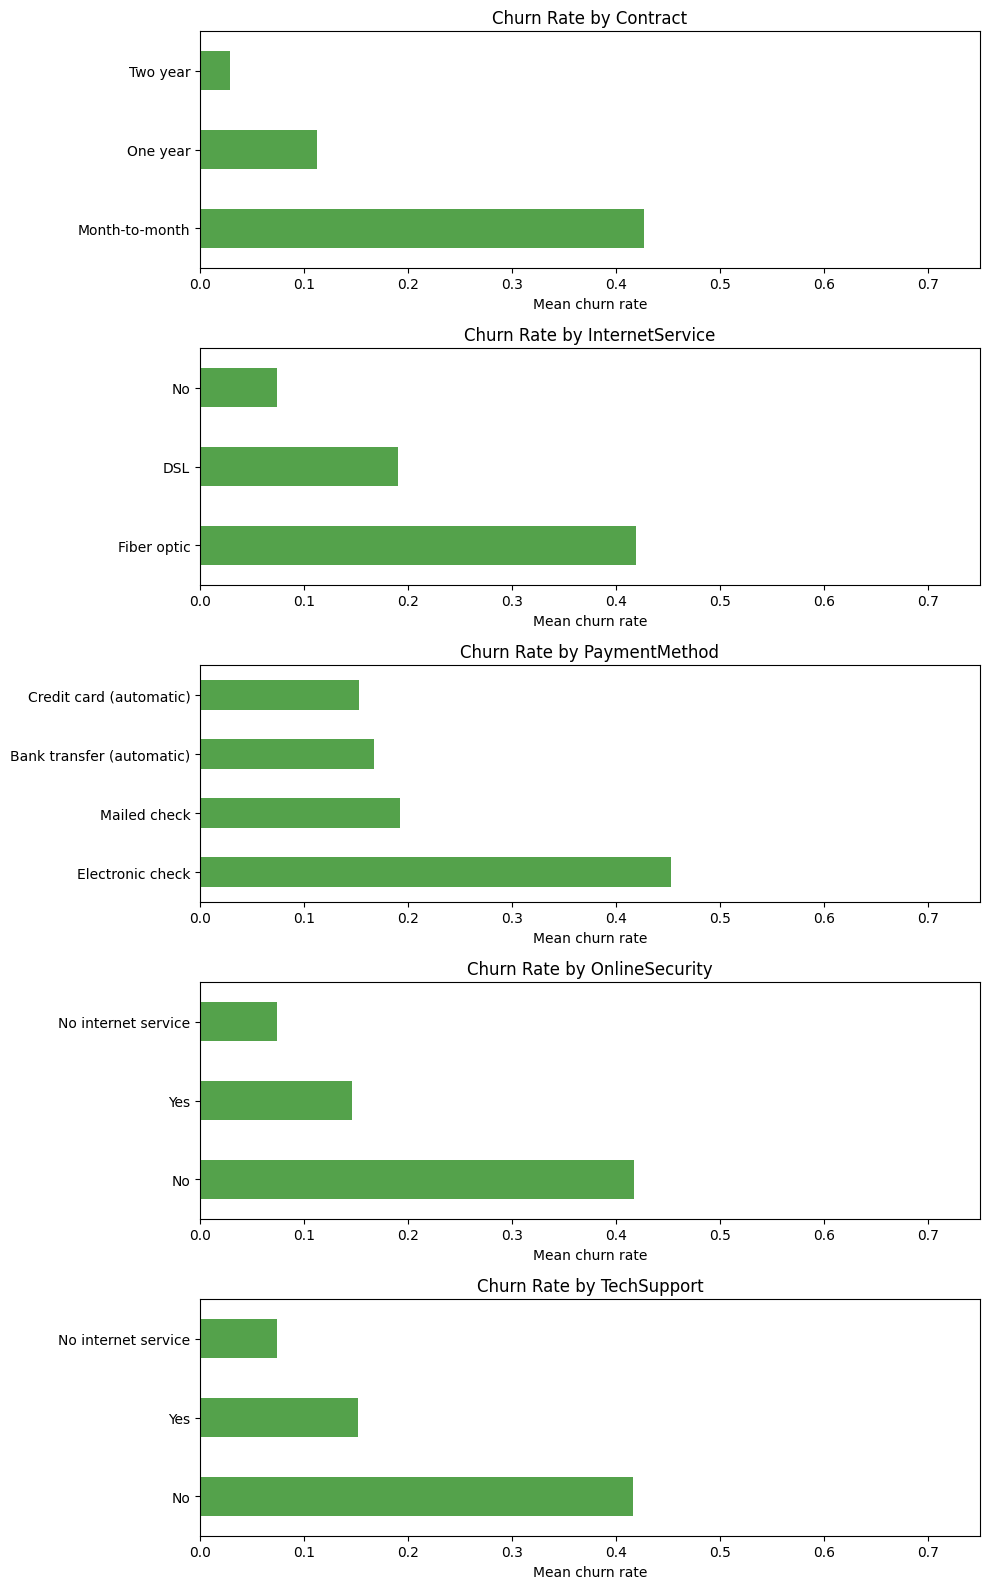

In [9]:
category_checks = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport"]
fig, axes = plt.subplots(len(category_checks), 1, figsize=(10, 16))

for ax, col in zip(axes, category_checks):
    churn_rate = df.groupby(col)["ChurnFlag"].mean().sort_values(ascending=False)
    churn_rate.plot(kind="barh", ax=ax, color="#54a24b")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_xlabel("Mean churn rate")
    ax.set_ylabel("")
    ax.set_xlim(0, max(0.75, churn_rate.max() + 0.05))

plt.tight_layout()
plt.show()

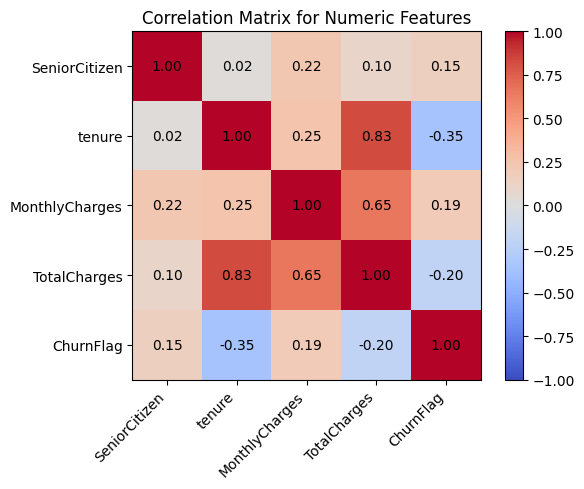

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChurnFlag
SeniorCitizen,1.000,0.016,0.220,0.102,0.151
tenure,0.016,1.000,0.247,0.826,-0.354
MonthlyCharges,0.220,0.247,1.000,0.651,0.193
TotalCharges,0.102,0.826,0.651,1.000,-0.199
ChurnFlag,0.151,-0.354,0.193,-0.199,1.000


In [10]:
corr = df[numeric_features + ["ChurnFlag"]].corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_title("Correlation Matrix for Numeric Features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

corr.round(3)

The numeric correlation matrix shows that `TotalCharges` is strongly related to `tenure` and moderately related to `MonthlyCharges`. This is expected because total charges accumulate over time.

#### Initial VIF check

VIF helps identify predictors that overlap with other predictors. It does not tell me the exact cause by itself, so I interpret the high values using the feature names and the dataset meaning.

In [11]:
def calculate_vif(data, numeric_cols, categorical_cols):
    try:
        encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)

    encoded_cats = encoder.fit_transform(data[categorical_cols])
    encoded_cat_names = encoder.get_feature_names_out(categorical_cols)

    vif_matrix = pd.DataFrame(
        np.column_stack([data[numeric_cols].to_numpy(), encoded_cats]),
        columns=numeric_cols + list(encoded_cat_names),
    )
    vif_matrix = vif_matrix.loc[:, vif_matrix.nunique() > 1]

    vif_values = []
    for i, col in enumerate(vif_matrix.columns):
        try:
            vif = variance_inflation_factor(vif_matrix.values, i)
        except Exception:
            vif = np.nan
        vif_values.append((col, vif))

    return pd.DataFrame(vif_values, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)


initial_vif_df = calculate_vif(df.drop(columns=["Churn", "ChurnFlag"]), numeric_features, categorical_features)
initial_vif_df.head(15).round(2)

/Users/daisy/miniforge3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
11,InternetService_No,inf
12,OnlineSecurity_No internet service,inf
20,StreamingTV_No internet service,inf
18,TechSupport_No internet service,inf
16,DeviceProtection_No internet service,inf
14,OnlineBackup_No internet service,inf
22,StreamingMovies_No internet service,inf
7,PhoneService_Yes,1773.53
2,MonthlyCharges,866.09
10,InternetService_Fiber optic,148.50


The initial VIF table supports two modeling decisions:

1. Several `No internet service` indicators repeat the same information as `InternetService_No`.
2. `TotalCharges` overlaps with `tenure` and `MonthlyCharges`.

To make the linear regression coefficients easier to interpret, I simplify the repeated service categories and remove `TotalCharges` before training.

In [12]:
model_df = df.copy()

internet_addon_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

model_df[internet_addon_cols] = model_df[internet_addon_cols].replace("No internet service", "No")
model_df["MultipleLines"] = model_df["MultipleLines"].replace("No phone service", "No")
model_df = model_df.drop(columns=["TotalCharges"])

numeric_features = ["SeniorCitizen", "tenure", "MonthlyCharges"]
categorical_features = [
    col for col in model_df.columns
    if col not in numeric_features + ["Churn", "ChurnFlag"]
]

print("Simplified unavailable-service categories.")
print("Dropped variable: TotalCharges")
print(f"Modeling shape: {model_df.shape}")

Simplified unavailable-service categories.
Dropped variable: TotalCharges
Modeling shape: (7032, 20)


#### VIF after feature simplification

I rerun VIF on the modeling dataset to check whether the simplification improved the multicollinearity issue.

In [13]:
vif_df = calculate_vif(model_df.drop(columns=["Churn", "ChurnFlag"]), numeric_features, categorical_features)
vif_df.head(15).round(2)

,feature,VIF
2,MonthlyCharges,179.12
6,PhoneService_Yes,41.86
8,InternetService_Fiber optic,12.99
1,tenure,7.75
9,InternetService_No,6.74
15,StreamingMovies_Yes,4.27
14,StreamingTV_Yes,4.13
17,Contract_Two year,3.46
18,PaperlessBilling_Yes,2.96
20,PaymentMethod_Electronic check,2.95


The infinite VIF values are removed after simplifying the repeated service-status categories. `MonthlyCharges` still has a high VIF because it is tied to the services a customer has, but I keep it because the current bill amount is an important business feature.

### 3. Linear Regression Model

The model pipeline standardizes numeric features, one-hot encodes categorical features, and fits a linear regression model using the simplified modeling dataset.

In [14]:
X = model_df.drop(columns=["Churn", "ChurnFlag"])
y = model_df["ChurnFlag"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

try:
    categorical_transformer = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
except TypeError:
    categorical_transformer = OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)
y_pred_class = (y_pred >= 0.5).astype(int)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")

Training rows: 5625
Test rows: 1407


### 4. Model Performance Evidence

I evaluate the model as a regression model first. Then I apply a `0.5` threshold to see how it behaves as a simple churn classifier.

In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred_class)

performance = pd.DataFrame(
    {
        "metric": ["MAE", "MSE", "RMSE", "R2", "ROC-AUC", "Accuracy at 0.5 threshold"],
        "value": [mae, mse, rmse, r2, roc_auc, accuracy],
    }
)
performance["value"] = performance["value"].round(4)
performance

,metric,value
0,MAE,0.3102
1,MSE,0.1453
2,RMSE,0.3812
3,R2,0.2555
4,ROC-AUC,0.8307
5,Accuracy at 0.5 threshold,0.7982


In [16]:
print("Prediction range:")
print(f"Minimum predicted value: {y_pred.min():.3f}")
print(f"Maximum predicted value: {y_pred.max():.3f}")
print(f"Predictions below 0: {(y_pred < 0).sum()}")
print(f"Predictions above 1: {(y_pred > 1).sum()}")

cm = confusion_matrix(y_test, y_pred_class)
cm_df = pd.DataFrame(cm, index=["Actual no churn", "Actual churn"], columns=["Predicted no churn", "Predicted churn"])
cm_df

Prediction range:
Minimum predicted value: -0.204
Maximum predicted value: 0.781
Predictions below 0: 237
Predictions above 1: 0


,Predicted no churn,Predicted churn
Actual no churn,930,103
Actual churn,181,193


In [17]:
print(classification_report(y_test, y_pred_class, target_names=["No churn", "Churn"]))

              precision    recall  f1-score   support

    No churn       0.84      0.90      0.87      1033
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



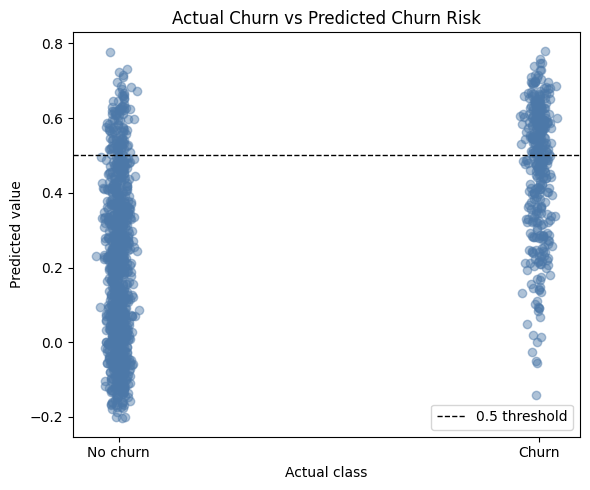

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
jitter = np.random.default_rng(RANDOM_STATE).normal(0, 0.015, size=len(y_test))
ax.scatter(y_test + jitter, y_pred, alpha=0.45, color="#4c78a8")
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="0.5 threshold")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No churn", "Churn"])
ax.set_title("Actual Churn vs Predicted Churn Risk")
ax.set_xlabel("Actual class")
ax.set_ylabel("Predicted value")
ax.legend()
plt.tight_layout()
plt.show()

### Post-Fit Residual Assumption Checks

Some assumption checks require a fitted model because they use predictions and residuals. This is where I check residual patterns, residual variance, residual normality, and independence.

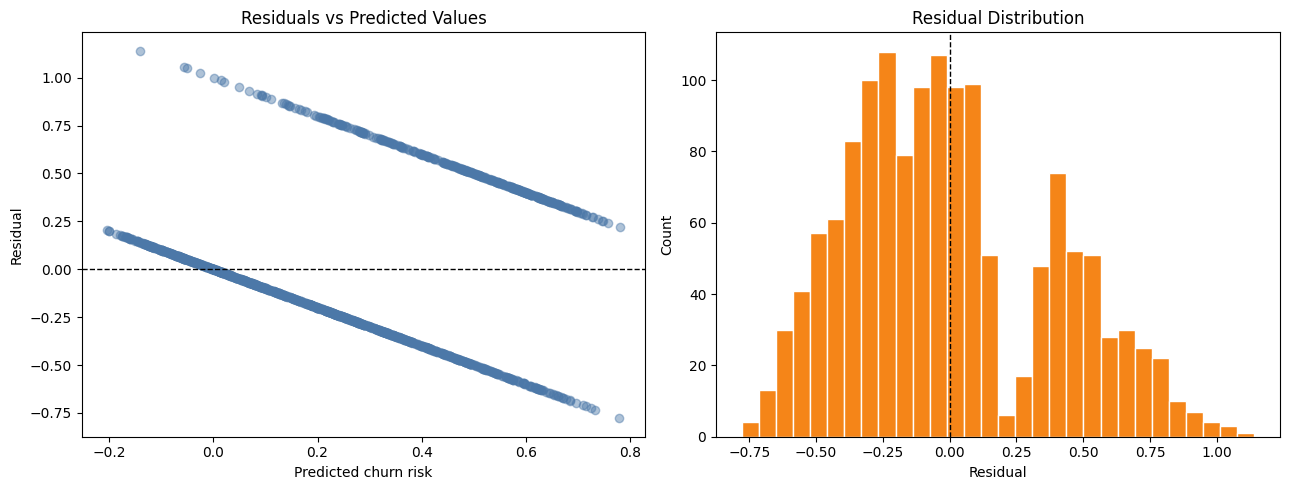

In [19]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred, residuals, alpha=0.45, color="#4c78a8")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Residuals vs Predicted Values")
axes[0].set_xlabel("Predicted churn risk")
axes[0].set_ylabel("Residual")

axes[1].hist(residuals, bins=30, color="#f58518", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [20]:
processed_X_test = linear_model.named_steps["preprocessor"].transform(X_test)
if hasattr(processed_X_test, "toarray"):
    processed_X_test = processed_X_test.toarray()

bp_stat, bp_pvalue, _, _ = het_breuschpagan(
    residuals,
    np.column_stack([np.ones(processed_X_test.shape[0]), processed_X_test]),
)
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)
dw_stat = durbin_watson(residuals)
max_vif = vif_df["VIF"].replace([np.inf, -np.inf], np.nan).dropna().max()

assumption_summary = pd.DataFrame(
    {
        "assumption": [
            "Linearity",
            "Homoscedasticity",
            "Normal residuals",
            "Independence",
            "No severe multicollinearity",
        ],
        "diagnostic": [
            "Residuals vs predicted plot",
            "Breusch-Pagan test",
            "Jarque-Bera test and Q-Q plot",
            "Durbin-Watson statistic",
            "VIF after feature simplification",
        ],
        "result": [
            "Residual bands appear because churn is binary",
            f"p-value = {bp_pvalue:.4g}",
            f"p-value = {jb_pvalue:.4g}; skew = {skew:.2f}; kurtosis = {kurtosis:.2f}",
            f"Durbin-Watson = {dw_stat:.2f}",
            f"Highest VIF = {max_vif:.2f}",
        ],
    }
)

assumption_summary

,assumption,diagnostic,result
0,Linearity,Residuals vs predicted plot,Residual bands appear because churn is binary
1,Homoscedasticity,Breusch-Pagan test,p-value = 2.268e-52
2,Normal residuals,Jarque-Bera test and Q-Q plot,p-value = 3.026e-16; skew = 0.48; kurtosis = 2.47
3,Independence,Durbin-Watson statistic,Durbin-Watson = 2.03
4,No severe multicollinearity,VIF after feature simplification,Highest VIF = 179.12


**Interpretation:** The assumption checks show that linear regression is not a perfect match for churn. The residual bands, Breusch-Pagan result, and Q-Q plot suggest issues with linearity, constant variance, and residual normality. Independence is likely acceptable because each row is a separate customer. Multicollinearity improved after simplifying service categories and dropping `TotalCharges`, but some overlap remains because service choices and monthly charges are naturally related.

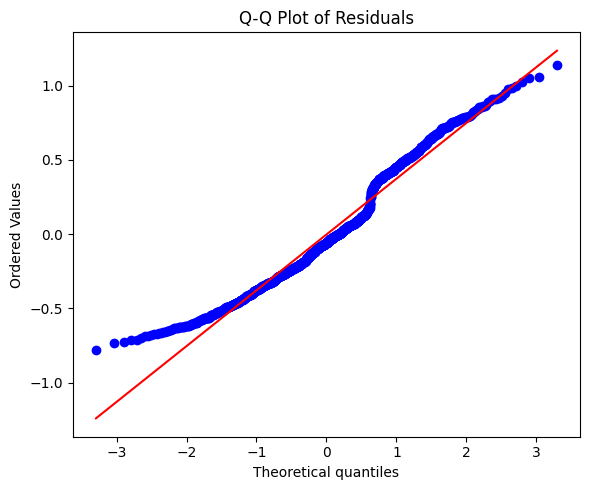

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

The post-fit checks confirm the main modeling decision: linear regression is easy to interpret, but the binary target causes assumption problems. I will use the model for explanation rather than claim it is the best classifier.

### 5. Coefficient Interpretation

Coefficients show how each feature changes the predicted churn-risk score, holding other features constant. Numeric features are standardized, so their coefficients represent a one-standard-deviation increase. Categorical coefficients are relative to the dropped reference category.

In [22]:
fitted_preprocessor = linear_model.named_steps["preprocessor"]
fitted_regressor = linear_model.named_steps["regressor"]

cat_names = fitted_preprocessor.named_transformers_["categorical"].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_names)

coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": fitted_regressor.coef_,
    }
)
coef_df["absolute_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("absolute_coefficient", ascending=False)

coef_df.head(20).round(4)

,feature,coefficient,absolute_coefficient
8,InternetService_Fiber optic,0.3118,0.3118
9,InternetService_No,-0.3021,0.3021
2,MonthlyCharges,-0.2105,0.2105
16,Contract_One year,-0.1168,0.1168
1,tenure,-0.1092,0.1092
14,StreamingTV_Yes,0.1040,0.1040
15,StreamingMovies_Yes,0.1036,0.1036
7,MultipleLines_Yes,0.0816,0.0816
20,PaymentMethod_Electronic check,0.0803,0.0803
6,PhoneService_Yes,0.0783,0.0783


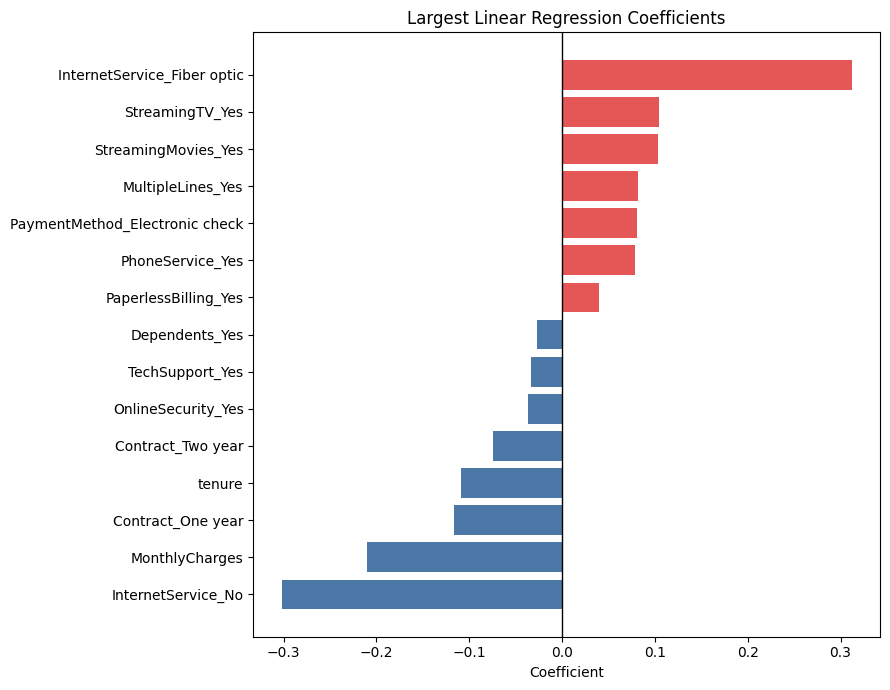

In [23]:
top_coefficients = coef_df.head(15).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#e45756" if value > 0 else "#4c78a8" for value in top_coefficients["coefficient"]]
ax.barh(top_coefficients["feature"], top_coefficients["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Largest Linear Regression Coefficients")
ax.set_xlabel("Coefficient")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [24]:
positive = coef_df.sort_values("coefficient", ascending=False).head(5)[["feature", "coefficient"]]
negative = coef_df.sort_values("coefficient", ascending=True).head(5)[["feature", "coefficient"]]

print("Features most associated with higher predicted churn risk:")
for _, row in positive.iterrows():
    print(f"- {row['feature']}: coefficient {row['coefficient']:.4f}")

print()
print("Features most associated with lower predicted churn risk:")
for _, row in negative.iterrows():
    print(f"- {row['feature']}: coefficient {row['coefficient']:.4f}")

Features most associated with higher predicted churn risk:
- InternetService_Fiber optic: coefficient 0.3118
- StreamingTV_Yes: coefficient 0.1040
- StreamingMovies_Yes: coefficient 0.1036
- MultipleLines_Yes: coefficient 0.0816
- PaymentMethod_Electronic check: coefficient 0.0803

Features most associated with lower predicted churn risk:
- InternetService_No: coefficient -0.3021
- MonthlyCharges: coefficient -0.2105
- Contract_One year: coefficient -0.1168
- tenure: coefficient -0.1092
- Contract_Two year: coefficient -0.0741


Positive coefficients are associated with higher predicted churn risk. In this model, fiber optic internet, streaming services, multiple lines, and electronic check payments are among the strongest positive signals.

Negative coefficients are associated with lower predicted churn risk. Longer contracts, tenure-related patterns, and some service categories are among the strongest negative signals. These are associations, not proof that changing one feature would directly cause churn to rise or fall.

### 6. Limitation of Using Linear Regression for Churn

The main limitation is that churn is binary, while linear regression predicts continuous values. Some predictions can fall below `0` or above `1`, which are not valid probabilities. A logistic regression model would usually be more appropriate for prediction, but linear regression is still useful here for simple coefficient-based interpretation.